<a href="https://colab.research.google.com/github/MazharZiadeh/gpu-nsga2-julia-fractals/blob/main/fractals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   	                    entropy                    	                         contrast                        	                               time                              
   	-----------------------------------------------	---------------------------------------------------------	-----------------------------------------------------------------
gen	avg    	gen	max    	min        	std    	avg     	gen	max     	min	std      	avg      	gen	max     	min        	std      
1  	1.74141	1  	5.23719	8.23433e-05	1.05431	0.10702 	1  	0.249012	0  	0.0580926	0.0138963	1  	0.165891	0.00187373 	0.0255868
2  	1.91992	2  	5.23719	9.26362e-05	1.21014	0.111209	2  	0.286897	0  	0.0573342	0.0160122	2  	0.165891	0.00187349 	0.0282267
3  	2.20718	3  	5.23719	0          	1.29924	0.13744 	3  	0.485889	0  	0.073636 	0.0209801	3  	0.165891	0.000545025	0.031815 
4  	2.08509	4  	5.23719	0          	1.21655	0.136978	4  	0.485889	0  	0.0874472	0.0167293	4  	0.165891	0.000545025	0.0276975
5  	2.08879	5  	5.23719

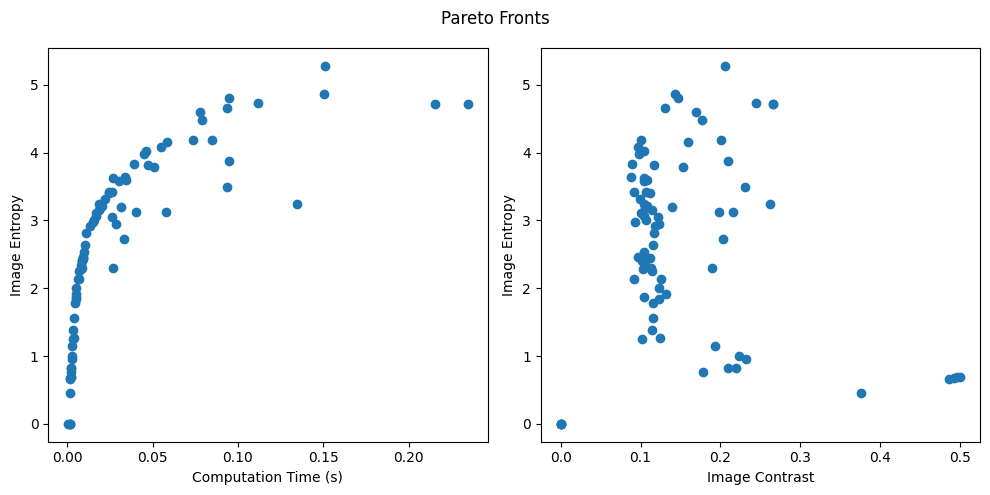

✅ evolution_results.xlsx saved
✅ results/combined_best_fractals.png saved


In [4]:
# ========================================================================
#  NSGA-II Evolution of Julia-Set Fractals
#  (Mazhar — ready to drop straight into Colab / Jupyter)
# ========================================================================

# --- Imports -------------------------------------------------------------
import random, os, time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import entropy
from deap import base, creator, tools, algorithms
from PIL import Image

# --- Scenario parameters -------------------------------------------------
scenario = "S3"          # choose: "S1", "S2", "S3"
params = {
    "S1": {"mu": 30, "lambda_": 70, "cxpb": 0.6, "mutpb": 0.4, "ngen": 30},
    "S2": {"mu": 70, "lambda_": 30, "cxpb": 0.9, "mutpb": 0.05, "ngen": 25},
    "S3": {"mu": 50, "lambda_": 50, "cxpb": 0.7, "mutpb": 0.2, "ngen": 20}
}[scenario]

# --- Julia-set generator -------------------------------------------------
def generate_julia(c: complex,
                   width: int, height: int,
                   xlim: tuple[float, float], ylim: tuple[float, float],
                   max_iter: int) -> np.ndarray:
    real = np.linspace(xlim[0], xlim[1], width)
    imag = np.linspace(ylim[0], ylim[1], height)
    Z = real[:, None] + 1j * imag[None, :]
    C = np.full_like(Z, c)
    M = np.zeros(Z.shape, dtype=int)
    mask = np.ones(Z.shape, bool)

    for i in range(max_iter):
        Z[mask] = Z[mask]**2 + C[mask]
        escaped = np.abs(Z) > 2
        M[mask & escaped] = i
        mask &= ~escaped
        if not mask.any():
            break
    return M

# --- Fitness evaluation --------------------------------------------------
def eval_fractal(individual):
    c = complex(individual[0], individual[1])
    zoom = individual[2]
    W = H = 200
    xlim = (-1.5/zoom, 1.5/zoom)
    ylim = (-1.5/zoom, 1.5/zoom)
    max_iter = int(100 * zoom)

    t0 = time.time()
    M = generate_julia(c, W, H, xlim, ylim, max_iter)
    comp_time = time.time() - t0

    max_M = np.max(M)
    norm_M = M if max_M == 0 else M / max_M

    hist, _ = np.histogram(M, bins=range(max_iter + 2), density=True)
    img_entropy  = entropy(hist + 1e-8)
    img_contrast = np.std(norm_M)

    # maximise entropy & contrast, minimise compute time
    return img_entropy, img_contrast, comp_time

# --- DEAP setup (safe for re-runs) ---------------------------------------
from deap import creator
if "FitnessMulti" in creator.__dict__:
    del creator.FitnessMulti
if "Individual"  in creator.__dict__:
    del creator.Individual

creator.create("FitnessMulti", base.Fitness, weights=(1.0, 1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_c_real", random.uniform, -1.0, 1.0)
toolbox.register("attr_c_imag", random.uniform, -1.0, 1.0)
toolbox.register("attr_zoom",  random.uniform,  0.5, 5.0)
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_c_real, toolbox.attr_c_imag, toolbox.attr_zoom), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", eval_fractal)
toolbox.register("mate",     tools.cxBlend,     alpha=0.5)
toolbox.register("mutate",   tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select",   tools.selNSGA2)

# --- Evolution parameters -------------------------------------------------
mu, lam, cxpb, mutpb, ngen = (params[k] for k in ("mu", "lambda_", "cxpb", "mutpb", "ngen"))
pop = toolbox.population(n=mu)

# ★ Evaluate the initial population so every individual has a fitness ★
for ind in pop:
    ind.fitness.values = toolbox.evaluate(ind)

# --- Pareto front & statistics -------------------------------------------
class ParetoFrontWithGen(tools.ParetoFront):
    def update(self, population):
        super().update(population)
        gen_now = logbook[-1]["gen"] if logbook else 0
        for ind in self:
            if not hasattr(ind, "generation"):
                ind.generation = gen_now

hof = ParetoFrontWithGen()

# per-objective stats
stat_entropy  = tools.Statistics(lambda ind: ind.fitness.values[0])
stat_contrast = tools.Statistics(lambda ind: ind.fitness.values[1])
stat_time     = tools.Statistics(lambda ind: ind.fitness.values[2])
for s in (stat_entropy, stat_contrast, stat_time):
    s.register("avg", np.mean)
    s.register("std", np.std)
    s.register("min", np.min)
    s.register("max", np.max)

stats = tools.MultiStatistics(entropy=stat_entropy,
                              contrast=stat_contrast,
                              time=stat_time)

logbook = tools.Logbook()
logbook.header = ["gen", "entropy", "contrast", "time"]

# --- Main evolutionary loop ----------------------------------------------
for gen in range(1, ngen + 1):
    offspring = algorithms.varOr(pop, toolbox, lam, cxpb=cxpb, mutpb=mutpb)

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind, fit in zip(invalid, toolbox.map(toolbox.evaluate, invalid)):
        ind.fitness.values = fit

    hof.update(offspring)
    pop[:] = toolbox.select(pop + offspring, mu)

    record = stats.compile(pop)
    logbook.record(gen=gen, **record)

print(logbook)

# --- Pareto-front visualisation ------------------------------------------
front = np.array([ind.fitness.values for ind in hof])
entropies, contrasts, times = front[:,0], front[:,1], front[:,2]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(times, entropies)
plt.xlabel("Computation Time (s)"); plt.ylabel("Image Entropy")

plt.subplot(1,2,2)
plt.scatter(contrasts, entropies)
plt.xlabel("Image Contrast"); plt.ylabel("Image Entropy")

plt.suptitle("Pareto Fronts")
plt.tight_layout(); plt.show()

# --- Save results ---------------------------------------------------------
os.makedirs("best_fractals", exist_ok=True)
os.makedirs("results",       exist_ok=True)

records = [{
    "c_real": ind[0], "c_imag": ind[1], "zoom": ind[2],
    "entropy": ind.fitness.values[0],
    "contrast": ind.fitness.values[1],
    "compute_time": ind.fitness.values[2],
    "generation": getattr(ind, "generation", "N/A")
} for ind in hof]
pd.DataFrame(records).to_excel("results/evolution_results.xlsx", index=False)
print("✅ evolution_results.xlsx saved")

# --- Save best 20 images --------------------------------------------------
hof_sorted = sorted(hof, key=lambda ind: ind.fitness.values[0], reverse=True)
for idx, ind in enumerate(hof_sorted[:20]):
    c, zoom = complex(ind[0], ind[1]), ind[2]
    M = generate_julia(c, 600, 600,
                       (-1.5/zoom, 1.5/zoom), (-1.5/zoom, 1.5/zoom),
                       int(100*zoom))
    plt.figure(figsize=(6,6))
    plt.imshow(M.T, cmap="inferno",
               extent=(-1.5/zoom, 1.5/zoom, -1.5/zoom, 1.5/zoom))
    plt.axis("off")
    plt.title(f"Best #{idx} | H={ind.fitness.values[0]:.3f} | C={ind.fitness.values[1]:.3f}")
    plt.savefig(f"best_fractals/best_fractal_{idx}.png",
                bbox_inches="tight", pad_inches=0.1, dpi=150)
    plt.close()

# --- Combine images into 4×5 grid ----------------------------------------
def combine_images(folder, n, rows, cols, outfile):
    imgs = []
    for i in range(n):
        path = os.path.join(folder, f"best_fractal_{i}.png")
        if os.path.exists(path):
            imgs.append(Image.open(path))
    if not imgs:
        print("No images found."); return
    w,h = imgs[0].size
    canvas = Image.new("RGB", (cols*w, rows*h))
    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx < len(imgs):
                canvas.paste(imgs[idx], (c*w, r*h))
                idx += 1
    canvas.save(outfile)
    print(f"✅ {outfile} saved")

combine_images("best_fractals", 20, 4, 5, "results/combined_best_fractals.png")


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from sklearn.preprocessing import MinMaxScaler
import os

# Load the uploaded Excel file
file_path = "/content/results/evolution_results.xlsx"
df = pd.read_excel(file_path, index_col=0)

# Normalize entropy, contrast (maximize), and compute_time (minimize => invert and normalize)
df_norm = df.copy()
scaler = MinMaxScaler()

df_norm[['entropy', 'contrast']] = scaler.fit_transform(df[['entropy', 'contrast']])
df_norm['compute_time'] = 1 - scaler.fit_transform(df[['compute_time']])  # Invert for maximization logic

# === Plot Normalized Pareto Front 1: Time vs Entropy ===
os.makedirs("results2", exist_ok=True)
plt.figure(figsize=(6, 5))
plt.scatter(df_norm['compute_time'], df_norm['entropy'], c='red')
plt.xlabel("Normalized Computation Time (maximized)")
plt.ylabel("Normalized Image Entropy")
plt.title("Normalized Pareto: Time vs Entropy")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/normalized_pareto_time_entropy.png", dpi=300)
plt.close()

# === Plot Normalized Pareto Front 2: Contrast vs Entropy ===
plt.figure(figsize=(6, 5))
plt.scatter(df_norm['contrast'], df_norm['entropy'], c='blue')
plt.xlabel("Normalized Image Contrast")
plt.ylabel("Normalized Image Entropy")
plt.title("Normalized Pareto: Contrast vs Entropy")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/normalized_pareto_contrast_entropy.png", dpi=300)
plt.close()

# === Spread Metric Calculation ===
def compute_spread_metric(pareto_points):
    pareto_points = np.array(pareto_points)
    pareto_points = pareto_points[np.argsort(pareto_points[:, 0])]
    distances = [euclidean(p1, p2) for p1, p2 in zip(pareto_points[:-1], pareto_points[1:])]
    d_bar = np.mean(distances)
    delta = sum(abs(d - d_bar) for d in distances) / (len(distances) * d_bar) if d_bar != 0 else 0
    return delta

spread_time_entropy = compute_spread_metric(df_norm[['compute_time', 'entropy']].values)
spread_contrast_entropy = compute_spread_metric(df_norm[['contrast', 'entropy']].values)

# Save spread metric
with open("results/spread_metrics.txt", "w") as f:
    f.write(f"Spread (Time vs Entropy): {spread_time_entropy:.4f}\n")
    f.write(f"Spread (Contrast vs Entropy): {spread_contrast_entropy:.4f}\n")

# === Convergence Plot (if generation info exists) ===
if 'generation' in df.columns:
    df_grouped = df.groupby('generation').agg({
        'entropy': 'mean',
        'contrast': 'mean',
        'compute_time': 'mean'
    }).reset_index()

    plt.figure(figsize=(10, 6))
    plt.plot(df_grouped['generation'], df_grouped['entropy'], label='Entropy')
    plt.plot(df_grouped['generation'], df_grouped['contrast'], label='Contrast')
    plt.plot(df_grouped['generation'], df_grouped['compute_time'], label='Compute Time')
    plt.xlabel("Generation")
    plt.ylabel("Objective Value")
    plt.title("Convergence Over Generations")
    plt.legend()
    plt.grid(True)
    plt.savefig("results/convergence_over_generations.png", dpi=300)
    plt.close()

df_norm.head(10)


,c_imag,zoom,entropy,contrast,compute_time,generation
c_real,,,,,,
0.153319,-0.588060,4.304935,1.000000,0.437089,0.000000,19
0.153319,-0.588060,4.304935,0.999920,0.436932,0.000064,1
0.274231,-0.485024,5.821360,0.979121,0.298423,0.070574,17
-0.311112,-0.630619,4.238246,0.957635,0.308709,0.359739,18
-0.309246,-0.640014,3.694295,0.939887,0.335827,0.378166,16
0.303584,-0.572698,4.957320,0.924936,0.348154,0.180402,9
-0.075389,-0.656095,2.803352,0.895476,0.371457,0.449249,14
-0.692368,0.346028,2.791039,0.877962,0.399970,0.369214,16
-0.545067,-0.543666,3.298914,0.861205,0.267140,0.537169,15


In [2]:
!pip install numpy matplotlib pandas deap scipy scikit-learn pillow ace_tools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 6.2 MB/s eta 0:00:00
